In [64]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

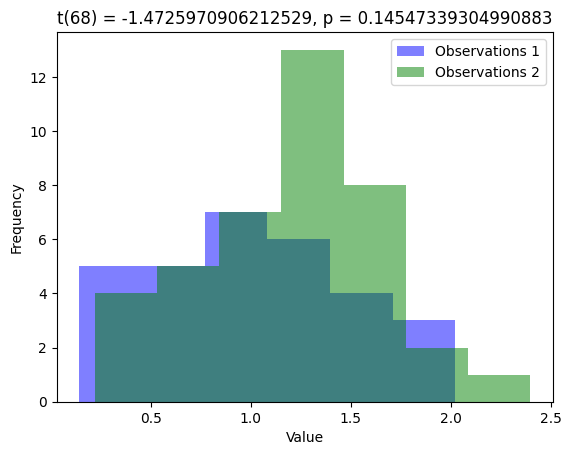

In [65]:
n1 = 30
n2 = 40

pop_mean1 = 1
pop_mean2 = 1.2

variance = .5

observations_1 = pop_mean1 + np.random.randn(n1) * variance
observations_2 = pop_mean2 + np.random.randn(n2) * variance

t, p = stats.ttest_ind(observations_1, observations_2, equal_var=True)

plt.hist(observations_1, bins='fd', color='blue', alpha=0.5, label='Observations 1')
plt.hist(observations_2, bins='fd', color='green', alpha=0.5, label='Observations 2')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title(f"t({n1 + n2 - 2}) = {t}, p = {p}")
plt.legend()

plt.show()

## 2D map of t values

In [66]:
mean_differences = np.linspace(-3, 3, 8)
pooled_variances = np.linspace(.5, 4, 10)

n1 = 40
n2 = 30

t_values = np.zeros((len(mean_differences), len(pooled_variances)))

for index_mean, mean_diff in enumerate(mean_differences):
    for index_var, var in enumerate(pooled_variances):

        # t-value denominator
        degrees_of_freedom = n1 + n2 - 2
        s = np.sqrt(( (n1-1) * var + (n2-1) * var ) / degrees_of_freedom)
        denominator = s * np.sqrt(1/n1 + 1/n2)

        # t-value in the matrix
        t_values[index_mean, index_var] = mean_diff / denominator

t_values

array([[-17.56620131, -13.17465098, -10.98841852,  -9.62140471,
         -8.66359712,  -7.94461347,  -7.37928056,  -6.9196657 ,
         -6.53645735,  -6.21059003],
       [-12.54728665,  -9.41046499,  -7.84887037,  -6.87243193,
         -6.18828366,  -5.6747239 ,  -5.27091468,  -4.94261836,
         -4.66889811,  -4.43613574],
       [ -7.52837199,  -5.64627899,  -4.70932222,  -4.12345916,
         -3.71297019,  -3.40483434,  -3.16254881,  -2.96557101,
         -2.80133887,  -2.66168144],
       [ -2.50945733,  -1.882093  ,  -1.56977407,  -1.37448639,
         -1.23765673,  -1.13494478,  -1.05418294,  -0.98852367,
         -0.93377962,  -0.88722715],
       [  2.50945733,   1.882093  ,   1.56977407,   1.37448639,
          1.23765673,   1.13494478,   1.05418294,   0.98852367,
          0.93377962,   0.88722715],
       [  7.52837199,   5.64627899,   4.70932222,   4.12345916,
          3.71297019,   3.40483434,   3.16254881,   2.96557101,
          2.80133887,   2.66168144],
       [ 1

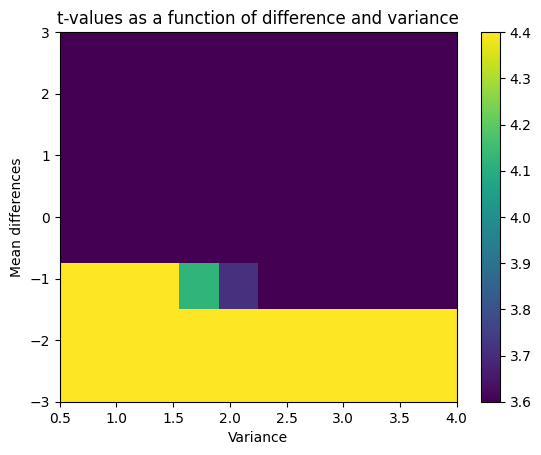

In [67]:


plt.imshow(
    t_values,
    vmin=4,
    vmax=4,
    extent=(pooled_variances[0], pooled_variances[-1], mean_differences[0], mean_differences[-1]),
    aspect='auto'
)

plt.xlabel('Variance')
plt.ylabel('Mean differences')
plt.colorbar()
plt.title('t-values as a function of difference and variance')

plt.show()
